# Polynomial Interpolation: Lagrange, Newton, NumPy and SciPy

**Author:** Alberto Reyes Castro  
**Original context:** Computational Physics coursework, BSc Physics  
**Public portfolio version:** English translation, cleaned formatting and reproducible code.

This notebook is a faithful public version of the original interpolation coursework. It implements polynomial interpolation using the Lagrange and Newton forms, compares both approaches, and then contrasts them with NumPy linear interpolation and SciPy cubic splines.

## Coursework Task

Implement the interpolating polynomial using the Lagrange and Newton forms. As an example dataset, the following values are used:

| x | y |
|---:|---:|
| -1.00 | 0.03846 |
| -0.75 | 0.06639 |
| -0.50 | 0.13793 |
| -0.25 | 0.39024 |
| 0.00 | 1.00000 |
| 0.25 | 0.39024 |
| 0.50 | 0.13793 |
| 0.75 | 0.06639 |
| 1.00 | 0.03846 |

A second example of interest is also presented and discussed. The implemented methods are compared with interpolation procedures already available in NumPy and SciPy.

## Theoretical Background

Lagrange and Newton interpolation are two different ways of constructing the same interpolating polynomial through a given set of points.

Given a set of values $(x_i, y_i)$ for $i = 0, \ldots, n$, the goal is to find a polynomial $p(x)$ such that:

$$
p(x_i) = y_i
$$

for every interpolation node.

### Lagrange Form

The Lagrange method builds a set of basis polynomials and combines them linearly. The interpolating polynomial is:

$$
p_n(x) = \sum_{i=0}^{n} y_i \, l_i(x)
$$

with:

$$
l_i(x) =
\frac{\prod_{j=0,\,j\ne i}^{n}(x-x_j)}
{\prod_{j=0,\,j\ne i}^{n}(x_i-x_j)}
$$

If there are $N$ points, the interpolating polynomial has degree $N-1$.

The main drawback of the Lagrange form is that if a new point is added, the full interpolation basis usually needs to be recomputed.

### Newton Form

Newton interpolation uses divided differences. The polynomial can be written as:

$$
f_n(x) =
f(x_0)
+ (x-x_0)f[x_1,x_0]
+ (x-x_0)(x-x_1)f[x_2,x_1,x_0]
+ \cdots
$$

The finite divided difference of order $n$ is:

$$
f[x_n,x_{n-1},\ldots,x_0] =
\frac{
f[x_n,x_{n-1},\ldots,x_1] -
f[x_{n-1},\ldots,x_1,x_0]
}{x_n-x_0}
$$

Both Lagrange and Newton interpolation construct the same interpolating polynomial for the same dataset. Lagrange is usually easier to understand, while Newton is more computationally convenient, especially when adding additional points.

## Lagrange Interpolation

Interpolated value at x = 0.67: y = 0.319010134265881
Lagrange interpolating polynomial computed successfully.
53.6899128888889*x**8 - 1.77635683940025e-15*x**7 - 102.816142222222*x**6 - 1.4210854715202e-14*x**5 + 61.3678204444445*x**4 + 8.88178419700125e-15*x**3 - 13.2031311111111*x**2 + 2.22044604925031e-16*x + 1.0


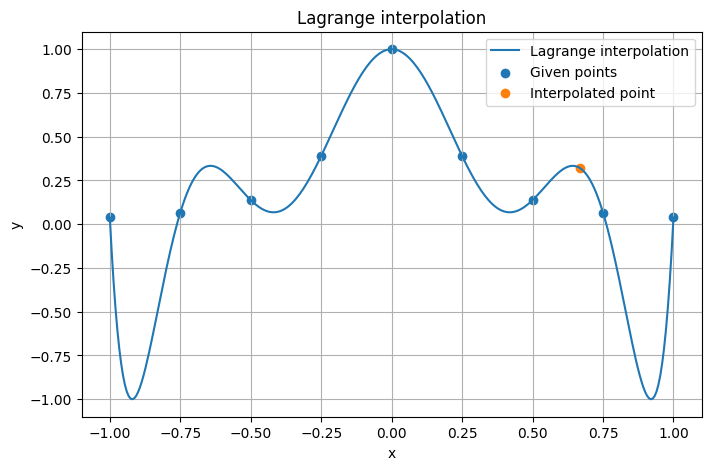

In [1]:
# Import the required modules
import numpy as np
import matplotlib.pyplot as plt
import sympy as sy
import scipy.interpolate as interpolate
import pandas as pd

# Original coursework dataset
x_values = [-1.0, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1.0]
y_values = [0.03846, 0.06639, 0.13793, 0.39024, 1, 0.39024, 0.13793, 0.06639, 0.03846]

x_symbol = sy.Symbol("x")

def lagrange_interpolation_symbolic(x_values, y_values):
    n = len(x_values)
    polynomial = 0

    for i in range(n):
        basis = 1

        for j in range(n):
            if i != j:
                basis *= (x_symbol - x_values[j]) / (x_values[i] - x_values[j])

        polynomial += y_values[i] * basis

    return sy.simplify(polynomial)

# Interpolation point used in the original coursework
x_interp = 0.67

lagrange_polynomial = lagrange_interpolation_symbolic(x_values, y_values)
y_interp = lagrange_polynomial.evalf(subs={x_symbol: x_interp})

print(f"Interpolated value at x = {x_interp}: y = {y_interp}")
print("Lagrange interpolating polynomial computed successfully.")
print(lagrange_polynomial)

x_grid = np.linspace(min(x_values), max(x_values), 300)
y_grid = np.array([lagrange_polynomial.evalf(subs={x_symbol: value}) for value in x_grid], dtype=float)

plt.figure(figsize=(8, 5))
plt.plot(x_grid, y_grid, label="Lagrange interpolation")
plt.scatter(x_values, y_values, label="Given points")
plt.scatter([x_interp], [float(y_interp)], label="Interpolated point")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Lagrange interpolation")
plt.legend()
plt.grid(True)
plt.show()

The previous code implements the Lagrange interpolation method for the given dataset.

The interpolating polynomial passes through all the supplied points and provides an interpolated value at $x=0.67$. For this dataset, the method gives a smooth curve through the nodes.

However, Lagrange interpolation can suffer from the Runge phenomenon, where oscillations become significant near the ends of the interpolation interval. It is also less computationally efficient for large datasets because the basis polynomials must be recomputed when the set of nodes changes.

## Newton Interpolation

Newton interpolating polynomial computed successfully.
53.6899128888889*x**8 - 102.816142222222*x**6 - 2.8421709430404e-14*x**5 + 61.3678204444444*x**4 - 8.88178419700125e-15*x**3 - 13.2031311111111*x**2 + 3.33066907387547e-16*x + 1.0
Interpolated value at x = 0.67: y = 0.31901013426587055


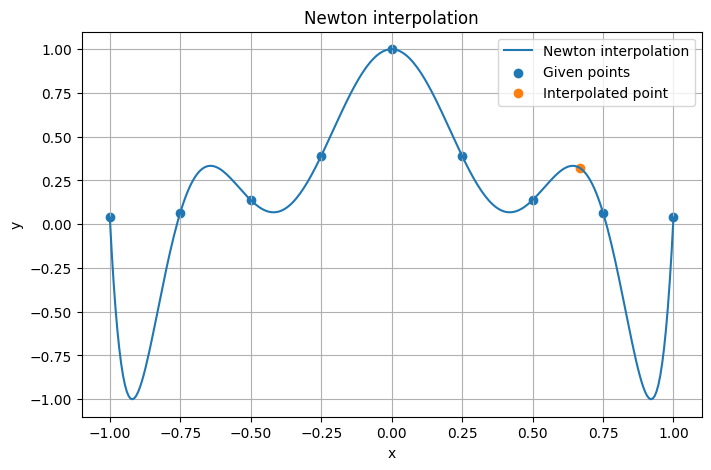

In [2]:
def newton_interpolation_function(x_values, y_values):
    n = len(x_values)
    coefficients = list(y_values).copy()

    # Divided differences
    for j in range(1, n):
        for i in range(n - 1, j - 1, -1):
            coefficients[i] = (coefficients[i] - coefficients[i - 1]) / (x_values[i] - x_values[i - j])

    def f(x):
        y = 0

        for i in range(n - 1, -1, -1):
            y = coefficients[i] + (x - x_values[i]) * y

        return y

    symbolic_polynomial = sy.simplify(f(x_symbol))
    print("Newton interpolating polynomial computed successfully.")
    print(symbolic_polynomial)

    return f, symbolic_polynomial

newton_function, newton_polynomial = newton_interpolation_function(x_values, y_values)

y_interp_newton = newton_function(x_interp)

print(f"Interpolated value at x = {x_interp}: y = {y_interp_newton}")

x_grid = np.linspace(min(x_values), max(x_values), 300)
y_grid = [newton_function(value) for value in x_grid]

plt.figure(figsize=(8, 5))
plt.plot(x_grid, y_grid, label="Newton interpolation")
plt.scatter(x_values, y_values, label="Given points")
plt.scatter([x_interp], [y_interp_newton], label="Interpolated point")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Newton interpolation")
plt.legend()
plt.grid(True)
plt.show()

## Important Note: Why Lagrange and Newton Give the Same Curve

Lagrange and Newton interpolation are not two different interpolation models. They are two different algebraic forms of the same unique interpolating polynomial.

For a fixed set of interpolation nodes:

```text
(x0, y0), (x1, y1), ..., (xn, yn)
```

there is only one polynomial of degree at most `n` that passes through all the points. Therefore, if the same nodes are used, the Lagrange and Newton forms produce the same final curve.

Their difference is mainly computational:

- **Lagrange interpolation** is easier to write and understand mathematically.
- **Newton interpolation** is more convenient when adding new points, because it uses divided differences.

The Runge phenomenon is not caused specifically by the Lagrange or Newton formula. It is caused by using a high-degree global polynomial with equally spaced interpolation nodes. Since Lagrange and Newton produce the same polynomial, both can show the same oscillations near the interval boundaries.

To reduce this effect, one would normally change the interpolation strategy, for example by using:

- Chebyshev nodes,
- piecewise interpolation,
- cubic splines,
- or lower-degree local interpolation.

## Comparison with NumPy and SciPy

The original coursework then compared the Lagrange and Newton interpolants with:

- NumPy linear interpolation
- SciPy cubic splines

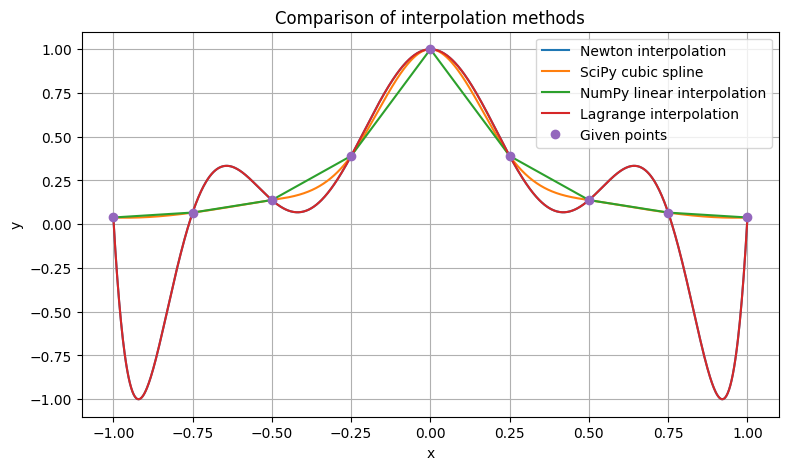

,method,value_at_x_0_67
0,Lagrange,0.319010
1,Newton,0.319010
2,NumPy linear,0.089283
3,SciPy cubic spline,0.087843


In [3]:
x_values_array = np.array(x_values, dtype=float)
y_values_array = np.array(y_values, dtype=float)

x_dense = np.linspace(x_values_array.min(), x_values_array.max(), 1000)

# NumPy linear interpolation
y_numpy = np.interp(x_dense, x_values_array, y_values_array)

# SciPy cubic spline interpolation
y_scipy = interpolate.CubicSpline(x_values_array, y_values_array)(x_dense)

# Newton interpolation
y_newton = np.array([newton_function(value) for value in x_dense], dtype=float)

# Lagrange interpolation
y_lagrange = np.array([lagrange_polynomial.evalf(subs={x_symbol: value}) for value in x_dense], dtype=float)

plt.figure(figsize=(9, 5))
plt.plot(x_dense, y_newton, label="Newton interpolation")
plt.plot(x_dense, y_scipy, label="SciPy cubic spline")
plt.plot(x_dense, y_numpy, label="NumPy linear interpolation")
plt.plot(x_dense, y_lagrange, label="Lagrange interpolation")
plt.plot(x_values_array, y_values_array, "o", label="Given points")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparison of interpolation methods")
plt.legend()
plt.grid(True)
plt.show()

comparison_at_target = pd.DataFrame(
    {
        "method": [
            "Lagrange",
            "Newton",
            "NumPy linear",
            "SciPy cubic spline",
        ],
        "value_at_x_0_67": [
            float(lagrange_polynomial.evalf(subs={x_symbol: x_interp})),
            float(newton_function(x_interp)),
            float(np.interp(x_interp, x_values_array, y_values_array)),
            float(interpolate.CubicSpline(x_values_array, y_values_array)(x_interp)),
        ],
    }
)

comparison_at_target

NumPy uses piecewise linear interpolation, joining neighbouring points with straight lines. SciPy's cubic spline interpolation uses smooth cubic curves between nodes.

Compared with Lagrange and Newton interpolation, the differences become more visible near the interval boundaries. This is where polynomial interpolation may show more noticeable oscillations, which is consistent with the Runge phenomenon.

In this particular dataset, cubic splines behave effectively and provide a smooth interpolation.

## Second Example: Interpolation of a Sine Function

The second case from the original coursework uses a sinusoidal function on the interval $[0, 4\pi]$ with nine equally spaced nodes. The same interpolation methods are compared again.

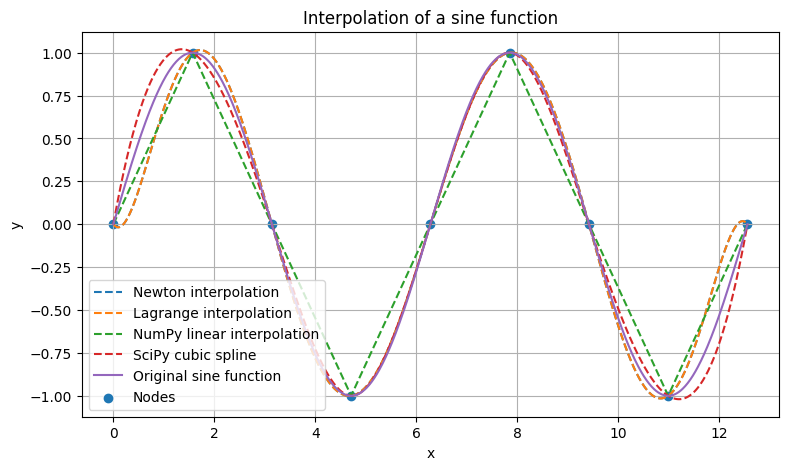

In [4]:
x_values_sine = np.linspace(0, 4 * np.pi, 9)
y_values_sine = np.sin(x_values_sine)

def newton_interpolation_numeric(x_values, y_values):
    n = len(x_values)
    coefficients = list(y_values).copy()

    for j in range(1, n):
        for i in range(n - 1, j - 1, -1):
            coefficients[i] = (coefficients[i] - coefficients[i - 1]) / (x_values[i] - x_values[i - j])

    def f(x):
        y = coefficients[-1]

        for i in range(n - 2, -1, -1):
            y = coefficients[i] + (x - x_values[i]) * y

        return y

    return f

def lagrange_interpolation_numeric(x_values, y_values, x_dense):
    n = len(x_values)
    y_dense = 0

    for i in range(n):
        numerator = 1
        denominator = 1

        for j in range(n):
            if i != j:
                numerator *= x_dense - x_values[j]
                denominator *= x_values[i] - x_values[j]

        y_dense += y_values[i] * numerator / denominator

    return y_dense

x_dense_sine = np.linspace(0, 4 * np.pi, 1000)

newton_sine_function = newton_interpolation_numeric(x_values_sine, y_values_sine)
y_newton_sine = np.array([newton_sine_function(value) for value in x_dense_sine])

y_lagrange_sine = lagrange_interpolation_numeric(x_values_sine, y_values_sine, x_dense_sine)
y_numpy_sine = np.interp(x_dense_sine, x_values_sine, y_values_sine)
y_scipy_sine = interpolate.CubicSpline(x_values_sine, y_values_sine)(x_dense_sine)
y_original_sine = np.sin(x_dense_sine)

plt.figure(figsize=(9, 5))
plt.plot(x_dense_sine, y_newton_sine, "--", label="Newton interpolation")
plt.plot(x_dense_sine, y_lagrange_sine, "--", label="Lagrange interpolation")
plt.plot(x_dense_sine, y_numpy_sine, "--", label="NumPy linear interpolation")
plt.plot(x_dense_sine, y_scipy_sine, "--", label="SciPy cubic spline")
plt.plot(x_dense_sine, y_original_sine, label="Original sine function")
plt.scatter(x_values_sine, y_values_sine, label="Nodes")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Interpolation of a sine function")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

For the sine function, the polynomial interpolants follow the sampled nodes, while NumPy linear interpolation is visibly less smooth because it only connects neighbouring points with straight segments.

SciPy cubic splines provide a smoother piecewise approximation and follow the original sine function more naturally in this example, especially between interpolation nodes.

Overall, this notebook preserves the structure of the original coursework while presenting the implementation, comparison and discussion in a clean public format.